# Proyecto Corte 3 con metodología CRISP-DM

### Grupo 4: Laura Franco, Martin Jerez, Sebastián Ulloa & Juliana Espinel

#### 20/11/2025

#### Analítica de datos 2025-2

## Librerías utilizadas

In [29]:
import matplotlib
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [5]:
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

NumPy: 1.26.4
Pandas: 2.2.3
Scikit-learn: 1.7.1
Matplotlib: 3.10.0


## 1. Introducción

Hoy en día, Spotify y Youtube, empresas fundadas en el 2006 y 2005 respectivamente, lideran mundialmente el streaming de música (audio y video). Al ser organizaciones de tan gran magnitud, producen una cantidad enorme de datos relacionados con el consumo de música y la interacción de los usuarios. Dentro de las interacciones de lo usuarios, un parametro muy importante son las reacciones en forma de likes, los cuales representan directamente el *engagement* de la audiencia, es decir, el nivel de aceptación y conexión que el contenido logra con los oyentes y/o expectadores.

Este notebook de Python, en el marco de la clase de Analítica de datos de La Universidad de La Sabana, expone el proyecto de segundo corte que busca aplicar los conceptos y algoritmos de Machine Learning supervisado estudiados en la materia para analizar los factores que influyen en los likes de un contenido subido en las plataformas mencionadas anteriormente. Para cumplir con este objetivo se toma como variable objetivo (target) la columna *Likes*, clasificada en dos categorías: alto engagement y bajo engagement, utilizando la mediana como el umbral. En el contexto de este proyecto se seleccionó la mediana como el umbral debido a que esta representa el punto medio real de la distribución de likes sin verse afectada por valores atípicos (outliers), por lo que garantiza que haya equilibrio en la clasificación de los datos (aproximadamente la mitad de los datos pertenezca a cada clase). Esto tiene sentido, ya que un contenido con alto engagement significa que está en la mitad superior de los datos, lo cual es intuitivo y menos sesgado a que si, por ejemplo, se utilizara la media.

Para cumplir con los requisitos y el proposito del proyecto, se utilizó el CRISP-DM (Proceso Estándar Intersectorial para la Minería de Datos) que consta de las siguiente 6 etapas:
1. **Comprensión del negocio**
2. **Comprensión de los datos**
3. **Preparación de los datos**
4. **Modelado**
5. **Evaluación**
6. **Despliegue**

Sin embargo, para el alcance de este proyecto, solo se trabajo hasta la etapa de evaluación, ya que es un alcance académico y el propósito es aplicar algoritmos supervisados, evaluarlos y comparar su desempeño.

## 2. Fases CRISP-DM

### 2.1. Comprensión del negocio

Este proyecto busca responder la pregunta de investigación que se ve a continuación.

¿Cómo pueden predecirse y entenderse los niveles de engagement (likes) en contenidos musicales a partir de interacciones y características cuantitativas (como vistas, comentarios, duración, etc.) presente en plataformas como YouTube y Spotify?

Para indagar en esta problematica, este proyecto busca aplicar nuevas técnicas de Machine Learning aprendidas durante el tercer corte de la materia Analítica de datos. Estas técnicas incluyen árboles de decisión, métodos de ensamble, reducción de dimensionalidad (PCA/LDA), balanceo de clases optimización de hiperparámetros, pipelines y validación cruzada. Se busca aplicar estos métodos para construir modelos que permitan predecir niveles altos y bajos de likes, y entender las variables predictorias que más afectan estas predicciones.

En resumne, se quiere lograr cumplir con el siguiente objetivo y responder las preguntas especificas que se plantean.

**Objetivo general:** Determinar qué factores explican el *engagement* de la audencia y evaluar que técnicas de Machine Learning permiten predecir con mayor precisión si una canción obtendra un nivel alto o bajo de likes.

**Preguntas especificas:**
- ¿Qué variables son las más influyentes sobre el número de likes de una canción?
- ¿Cómo influye cada variable predictoria en el nivel de engagement?
- ¿El dataset esta desbalanceado? Si sí, ¿cómo afecta el desempeño del modelo?
- ¿Los modelos de Machine Learning muestran diferencias entre su capacidad de detectar casos de alto y bajo engagement?
- ¿Qué técnica ofrece el mejor desempeño?

Adicionalmente, se establecieron unos límites para las métricas, con el fin de indicar a partir de cuál valor se toma como que el entrenamiento del modelo fue exitoso y el resultado fue un bueno modelo.

**Métricas de éxito:**
- Accuracy ≥ 80%
- Precision ≥ 75%
- Recall ≥ 70%
- Specificity ≥ 75%
- F1-score ≥ 75%
- AUC-ROC ≥ 0.80

Sin embargo, aunque las métricas de éxito indican cuando el modelo es bueno, no todas las métricas tienen el mismo nivel de prioridad. Las de primera prioridad son F1-score y Recall, ya que aseguran el equilibrio del modelo y la disminución de falsos negativos. Las de segunda prioridad son Precision y AUC-ROC debido a que ayudan a evitar un exceso de falsos positivos y muestran una evaluación global del rendimiento del modelo sin depender del umbral. Por último, Accuracy y Specificity son de tercera prioridad, ya que Accuracy depende mucho del umbral y Specificity se enfoca más en la identificación de casos de bajo engagement (en el contexto de este proyecto es más importante la identificación de casos de alto engagement), por lo que no son tan importantes como las anteriores.

### 2.2. Comprensión de los datos

En esta etapa del CRISP-DM es donde se interactua con el dataset por primera vez pero, sin embargo, no se modificán los datos ni se les hace ningun tipo de transformaciones. A continuación se puede observar que en esta sección simplemente se carga el data set "Datos_proyecto_C1_Spotify_Youtube.csv" al notebook como un dataframe y se muestran algunas propiedades del mismo. Sin ambargo, se creo un dataframe adicional con las columnas establecidas en la comprensión del negocio, ya que son las más relevantes de este proyecto. 

En primer lugar, se muestra información general para identificar los tipos de dato, y la cantidad de nulos y no nulos en cada columna. En segundo lugar, se muestran las primeras filas del dataset para poder saber con más precisión como se ven los datos de cada columna, y en tercer lugar, se muestran estadisticas básicas de cada columna con el fin de comprobar si alguna de ellas tenía datos estandarizados. En cuarto lugar, también se muestran los nombres de todas las columnas, ya que con otros comandos algunas de ellas queda excluidas, y esta información es bastante importante  debido a que es necesario saber con exactitud los nombres de las columnas para después poder hacerles transformaciones a las que se van a utilizar. 

Adicionalmente, se creó un nuevo dataframe solo con las columnas que son relevantes para este proyecto: Likes, Stream, Views, Comments y Duration_ms. A partir de este dataframe, nuevamente se sacó información y descripciones generales, pero también, se creó una gráfica. Se hizo una matriz de correlación (o mapa de calor) para averiguar cual, o cuales, variables predictoras afectan más a la cantidad de likes (entre más cercano a 1, mayor es la relación).

In [6]:
#se carga el archivo csv
archivo = r"Datos_proyecto_C1_Spotify_Youtube.csv"

#se define el data frame
df = pd.read_csv(archivo)

#print de información general y primeras filas
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20718 non-null  int64  
 1   Artist            20718 non-null  object 
 2   Url_spotify       20718 non-null  object 
 3   Track             20718 non-null  object 
 4   Album             20718 non-null  object 
 5   Album_type        20718 non-null  object 
 6   Uri               20718 non-null  object 
 7   Danceability      20716 non-null  float64
 8   Energy            20716 non-null  float64
 9   Key               20716 non-null  float64
 10  Loudness          20716 non-null  float64
 11  Speechiness       20716 non-null  float64
 12  Acousticness      20716 non-null  float64
 13  Instrumentalness  20716 non-null  float64
 14  Liveness          20716 non-null  float64
 15  Valence           20716 non-null  float64
 16  Tempo             20716 non-null  float6

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


In [7]:
df.columns

Index(['Unnamed: 0', 'Artist', 'Url_spotify', 'Track', 'Album', 'Album_type',
       'Uri', 'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo',
       'Duration_ms', 'Url_youtube', 'Title', 'Channel', 'Views', 'Likes',
       'Comments', 'Description', 'Licensed', 'official_video', 'Stream'],
      dtype='object')

In [8]:
cols_deseadas = ['Views','Comments','Duration_ms','Stream', 'Likes']
nuevo_df = df[cols_deseadas]
nuevo_df.info()
nuevo_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Views        20248 non-null  float64
 1   Comments     20149 non-null  float64
 2   Duration_ms  20716 non-null  float64
 3   Stream       20142 non-null  float64
 4   Likes        20177 non-null  float64
dtypes: float64(5)
memory usage: 809.4 KB


,Views,Comments,Duration_ms,Stream,Likes
0,693555221.0,169907.0,222640.0,1.040235e+09,6220896.0
1,72011645.0,31003.0,200173.0,3.100837e+08,1079128.0
2,8435055.0,7399.0,215150.0,6.306347e+07,282142.0
3,211754952.0,55229.0,233867.0,4.346636e+08,1788577.0
4,618480958.0,155930.0,340920.0,6.172597e+08,6197318.0


In [9]:
nuevo_df.describe()

,Views,Comments,Duration_ms,Stream,Likes
count,2.024800e+04,2.014900e+04,2.071600e+04,2.014200e+04,2.017700e+04
mean,9.393782e+07,2.751899e+04,2.247176e+05,1.359422e+08,6.633411e+05
std,2.746443e+08,1.932347e+05,1.247905e+05,2.441321e+08,1.789324e+06
min,0.000000e+00,0.000000e+00,3.098500e+04,6.574000e+03,0.000000e+00
25%,1.826002e+06,5.090000e+02,1.800095e+05,1.767486e+07,2.158100e+04
50%,1.450110e+07,3.277000e+03,2.132845e+05,4.968298e+07,1.244810e+05
75%,7.039975e+07,1.436000e+04,2.524430e+05,1.383581e+08,5.221480e+05
max,8.079649e+09,1.608314e+07,4.676058e+06,3.386520e+09,5.078865e+07


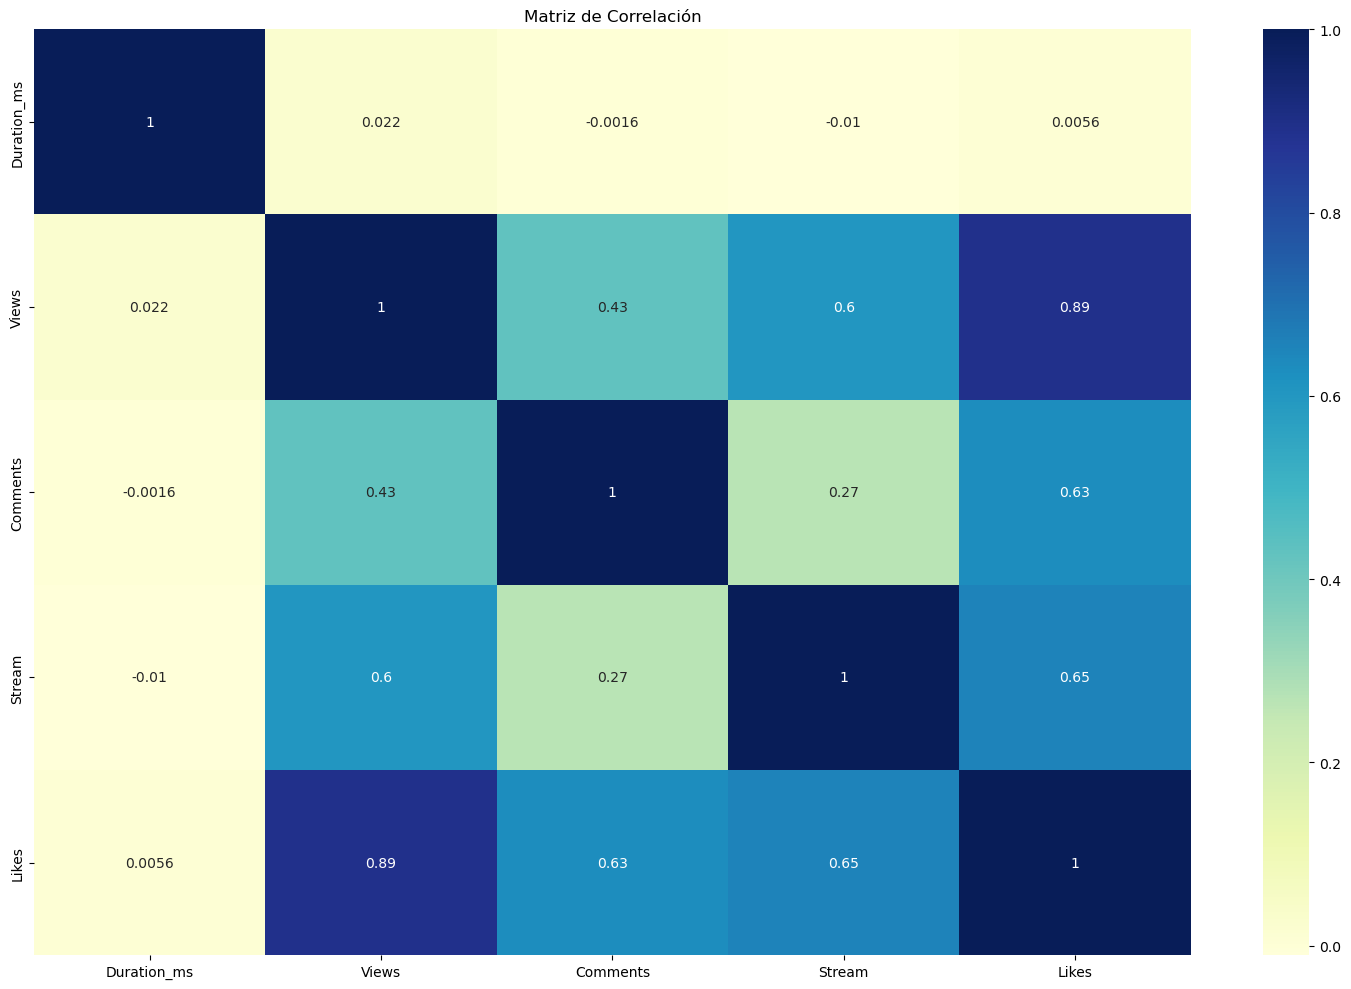

In [18]:
plt.figure(figsize=(15,10))
correlation = nuevo_df[[
       'Duration_ms', 'Views', 'Comments', 'Stream','Likes']].corr()
sns.heatmap(correlation, annot=True, cmap="YlGnBu")
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

La varible que más afecta a los likes (target) es la variable *Views*. En segundo lugar está *Stream*, aunque no esta muy lejos de *Comments*.

In [20]:
nulos_views = nuevo_df['Views'].isnull().sum()/len(nuevo_df) * 100
nulos_comments = nuevo_df['Comments'].isnull().sum()/len(nuevo_df) * 100
nulos_duration = nuevo_df['Duration_ms'].isnull().sum()/len(nuevo_df) * 100
nulos_stream = nuevo_df['Stream'].isnull().sum()/len(nuevo_df) * 100
nulos_likes = nuevo_df['Likes'].isnull().sum()/len(nuevo_df) * 100

print(f'Porcentaje de nulos en Views: {nulos_views:.3f}%')
print(f'Porcentaje de nulos en Comments: {nulos_comments:.3f}%')
print(f'Porcentaje de nulos en Duration_ms: {nulos_duration:.3f}%')
print(f'Porcentaje de nulos en Stream: {nulos_stream:.3f}%')
print(f'Porcentaje de nulos en Likes: {nulos_likes:.3f}%')

Porcentaje de nulos en Views: 2.269%
Porcentaje de nulos en Comments: 2.746%
Porcentaje de nulos en Duration_ms: 0.010%
Porcentaje de nulos en Stream: 2.780%
Porcentaje de nulos en Likes: 2.611%


In [21]:
neg_views = (nuevo_df['Views'] < 0).sum() / len(nuevo_df) * 100
neg_comments = (nuevo_df['Comments'] < 0).sum() / len(nuevo_df) * 100
neg_duration = (nuevo_df['Duration_ms'] < 0).sum() / len(nuevo_df) * 100
neg_stream = (nuevo_df['Stream'] < 0).sum() / len(nuevo_df) * 100
neg_likes = (nuevo_df['Likes'] < 0).sum() / len(nuevo_df) * 100

print(f'Porcentaje de negativos en Views: {neg_views:.3f}%')
print(f'Porcentaje de negativos en Comments: {neg_comments:.3f}%')
print(f'Porcentaje de negativos en Duration_ms: {neg_duration:.3f}%')
print(f'Porcentaje de negativos en Stream: {neg_stream:.3f}%')
print(f'Porcentaje de negativos en Likes: {neg_likes:.3f}%')

Porcentaje de negativos en Views: 0.000%
Porcentaje de negativos en Comments: 0.000%
Porcentaje de negativos en Duration_ms: 0.000%
Porcentaje de negativos en Stream: 0.000%
Porcentaje de negativos en Likes: 0.000%


### 2.3. Preparación de los datos

En esta sección se realizaron principalmente 4 actividades para transformar y preparar el dataset antes de entrenar modelos. Primero que todo, se realizó una limpieza de datos tomando en cuenta lo visto en la etapa de *Comprensión de los datos*: se eliminaron los valores nulos de cada variable. Después, se construyó la variable target utilizando la mediana como umbral, ya que es necesario tener una variable objetivo binaria (0 = nivel bajo, 1 = nivel alto) y no continua como la columna actual de Likes. Según la creación de la variable target, se determinó que las clases estaban balanceada y no fue necesario aplicar ninguna técnica de balanceo o reducción de dimensionalidad. También, se crearon dos variables nuevas para guardar las columnas de las variables predictoras y de la variable target. Por último, se hizo la división de los datos en train y test.

Gracias a que ninguno de los porcentajes de nulos en cada variable es mayor al 3%, las cantidades de valores vacíos se pueden considerar bajas, por lo que es posible hacer el siguiente poceso para borrarlas.

In [22]:
nuevo_df = nuevo_df.dropna(subset=["Views", "Comments", "Duration_ms", "Stream", "Likes"])
nuevo_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19549 entries, 0 to 20717
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Views        19549 non-null  float64
 1   Comments     19549 non-null  float64
 2   Duration_ms  19549 non-null  float64
 3   Stream       19549 non-null  float64
 4   Likes        19549 non-null  float64
dtypes: float64(5)
memory usage: 916.4 KB


In [25]:
# Se crea la variable objetivo binaria (alto/bajo engagement)
umbral = nuevo_df["Likes"].median()
nuevo_df["Engagement"] = np.where(nuevo_df["Likes"] >= umbral, 1, 0)

print("Distribución de la variable objetivo (Engagement):")
print(nuevo_df["Engagement"].value_counts())

Distribución de la variable objetivo (Engagement):
Engagement
1    9775
0    9774
Name: count, dtype: int64


La proporción es básicamente 50% - 50%, lo que demuestra que ni hay un desbalance significativo.

In [27]:
# Variables predictoras y variable objetivo
X = nuevo_df[["Views", "Comments", "Duration_ms", "Stream"]]
y = nuevo_df["Engagement"]

In [31]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamaño de los datos:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train distribución:\n", y_train.value_counts(normalize=True))
print("y_test distribución:\n", y_test.value_counts(normalize=True))

Tamaño de los datos:
X_train: (13684, 4) X_test: (5865, 4)
y_train distribución:
 Engagement
1    0.5
0    0.5
Name: proportion, dtype: float64
y_test distribución:
 Engagement
1    0.500085
0    0.499915
Name: proportion, dtype: float64


Después de la partición todavía se sigue el balanceo de clases de 50% - 50%.

### 2.4. Modelado

### 2.5. Evaluación

## 3. Hallazgos clave

## 4. Conclusiones

## 5. Recomendaciones